In [4]:
import gc
import os

import numpy as np
import pandas as pd
import dai
import torch

from transformer_train import MODEL_PATH, BATCH, StockTransformer, build_dataset, load_model


def main(datasources, start_date, end_date):
    table = datasources["bar1m"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cpu":
        torch.set_num_threads(min(4, os.cpu_count() or 1))
    checkpoint = load_model(MODEL_PATH, map_location=device)
    stats = (np.asarray(checkpoint["mean"], np.float32), np.asarray(checkpoint["std"], np.float32))
    model = StockTransformer(**checkpoint["model_cfg"]).to(device)
    model.load_state_dict(checkpoint["state_dict"], strict=True)
    model.eval()
    shared_gate = checkpoint["model_cfg"].get("model_variant") == "shared_gate"

    members = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    members["date"] = pd.to_datetime(members["date"], errors="coerce").dt.normalize()
    members["instrument"] = members["instrument"].astype(str)
    days = pd.DatetimeIndex(sorted(members["date"].dropna().unique()))
    outputs = []
    with torch.inference_mode():
        for date in days:
            day_members = members[members["date"] == date]
            instruments = day_members["instrument"].drop_duplicates().tolist()
            day_start = date.strftime("%Y-%m-%d 00:00:00")
            day_end = date.strftime("%Y-%m-%d 23:59:59")
            x, _, index, _ = build_dataset(table, day_start, day_end, "infer", instruments, stats)
            scores = []
            if shared_gate:
                whole_day = torch.from_numpy(x).to(device, non_blocking=True)
                gate = model.shared_gate_from_cross_section(whole_day)
                del whole_day
                for start in range(0, len(index), BATCH):
                    block = torch.from_numpy(x[start:start + BATCH]).to(device, non_blocking=True)
                    scores.append(model(block, shared_gate=gate).cpu().numpy())
                    del block
                del gate
            else:
                for start in range(0, len(index), BATCH):
                    block = torch.from_numpy(x[start:start + BATCH]).to(device, non_blocking=True)
                    scores.append(model(block).cpu().numpy())
                    del block
            index["score"] = np.concatenate(scores).astype(np.float64)
            outputs.append(index)
            del x, index, scores, day_members, instruments
            gc.collect()

    prediction = pd.concat(outputs, ignore_index=True)
    result = (prediction.merge(members, on=["date", "instrument"], how="inner")
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["score"])
        .drop_duplicates(["date", "instrument"])
        [["date", "instrument", "score"]]
        .reset_index(drop=True))
    return result


[2026-07-26 21:34:09] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-26 21:43:27] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-07-26 21:43:27] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-26 21:43:31] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-26 21:43:31] [info     ] 因子列名不为 factor, 自动重命名
[2026-07-26 21:43:32] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-26 21:43:32] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-07-26 21:43:32] [info     ] ========== 数据检查 ==========
[2026-07-26 21:43:32] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3',

时段,IC
2024-01-15~2024-02-08,0.0296
2024-09-24~2024-10-08,0.0892

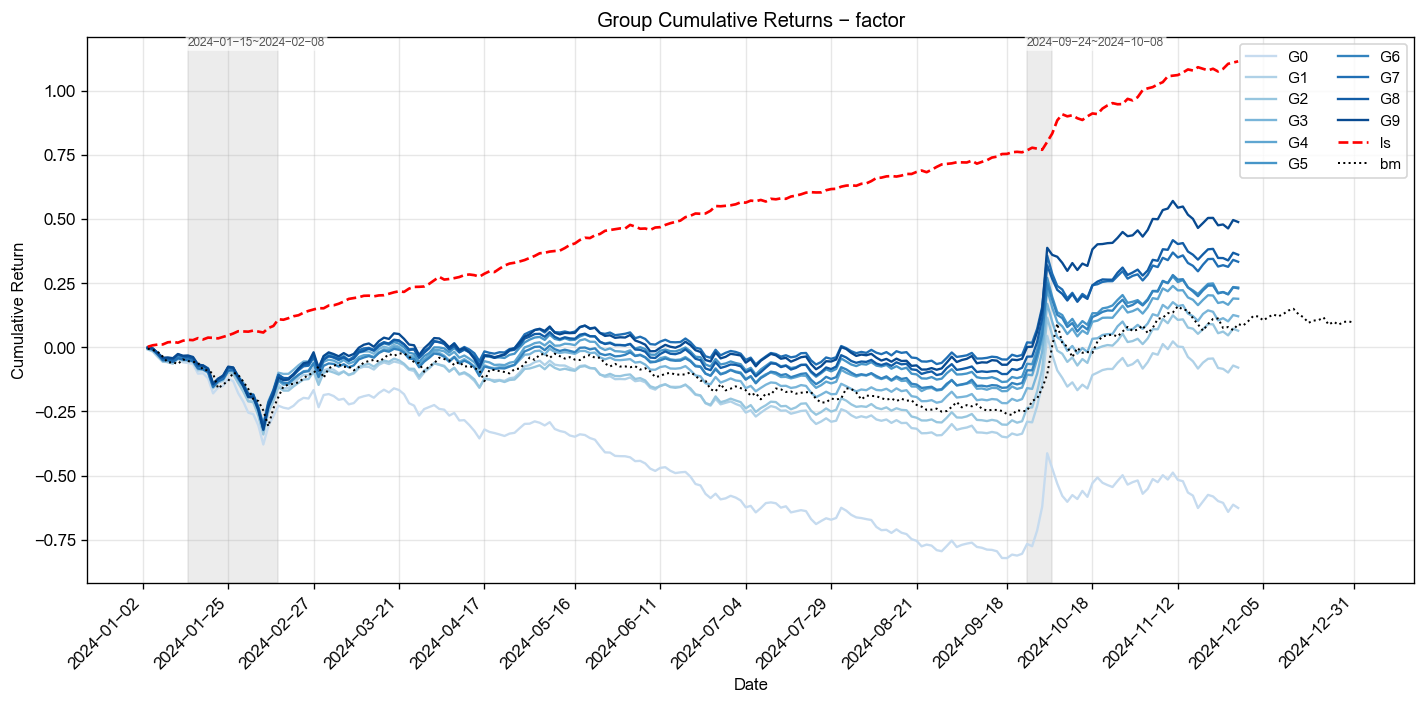
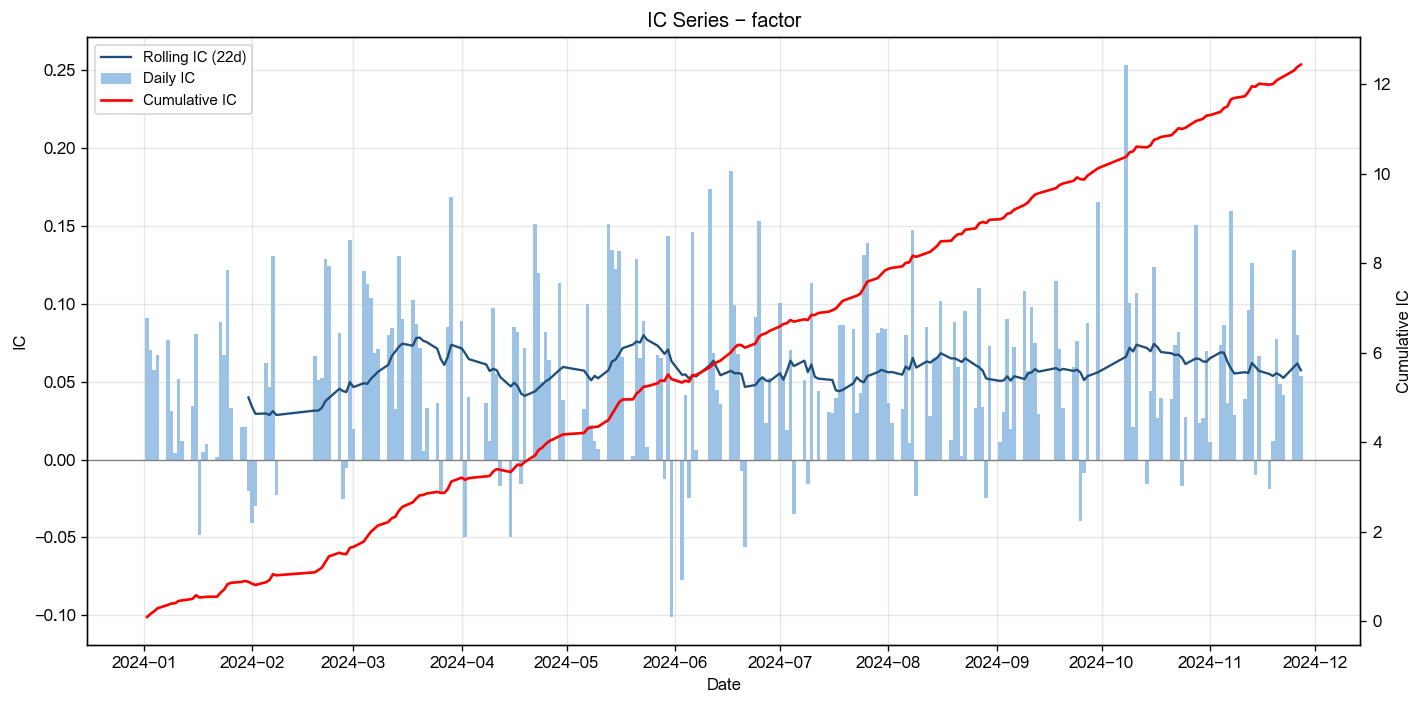
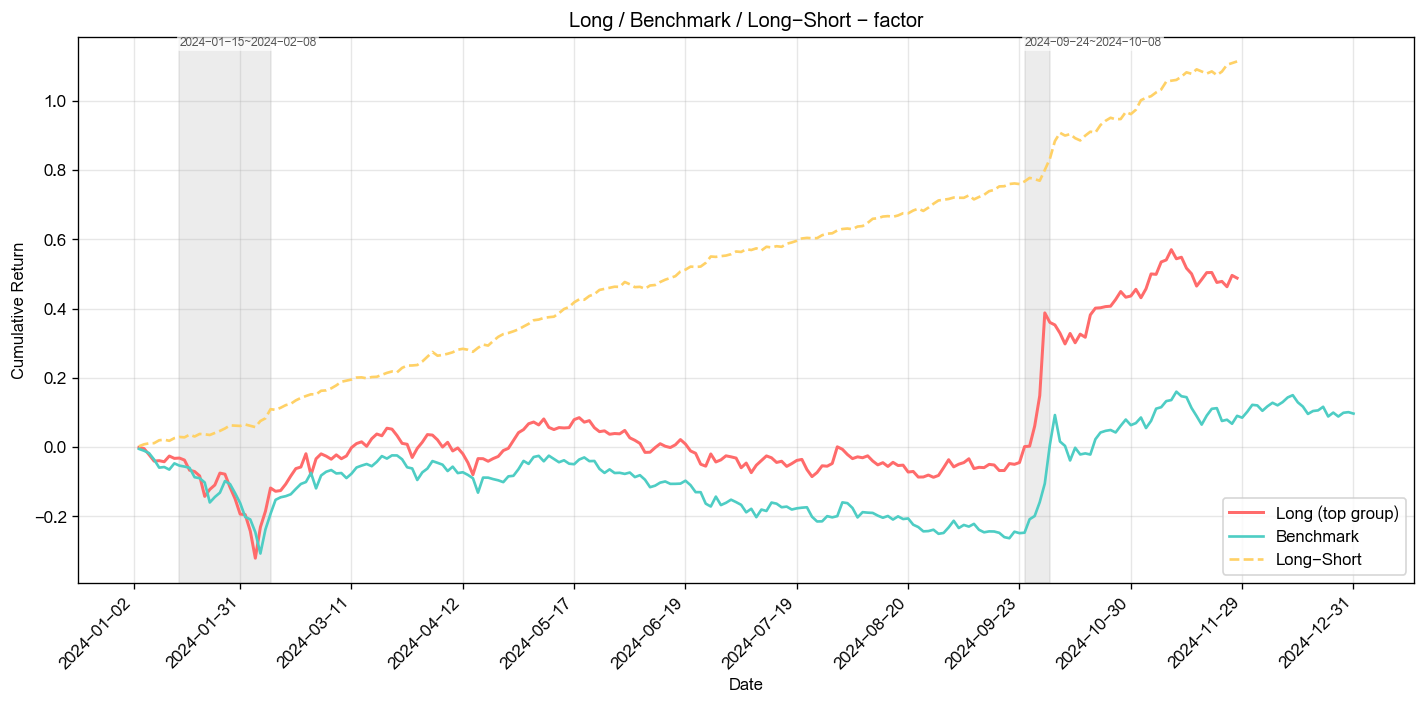
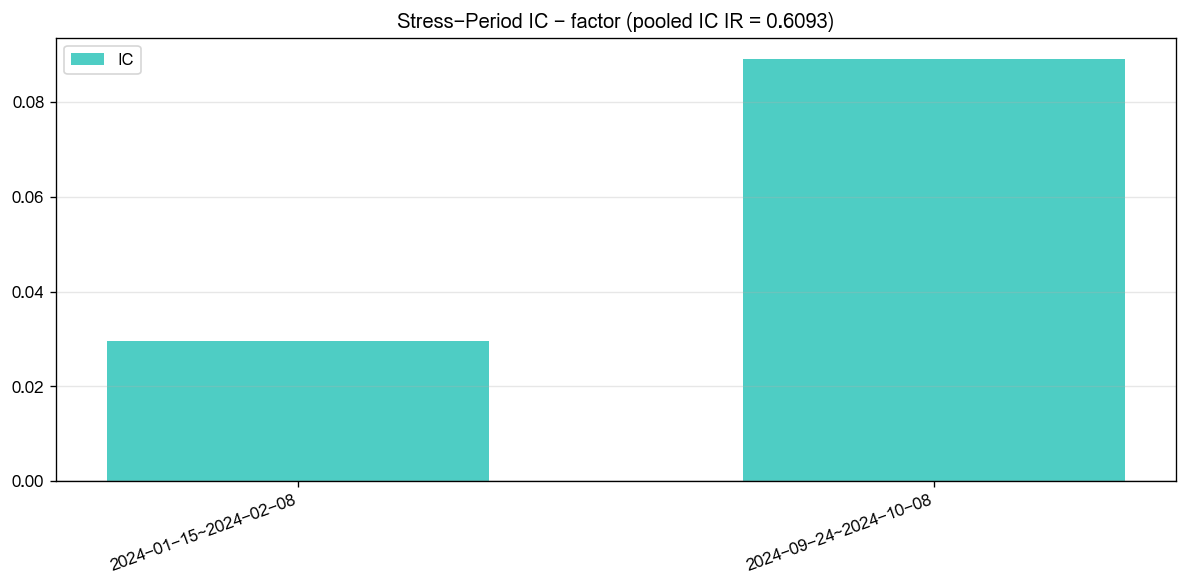
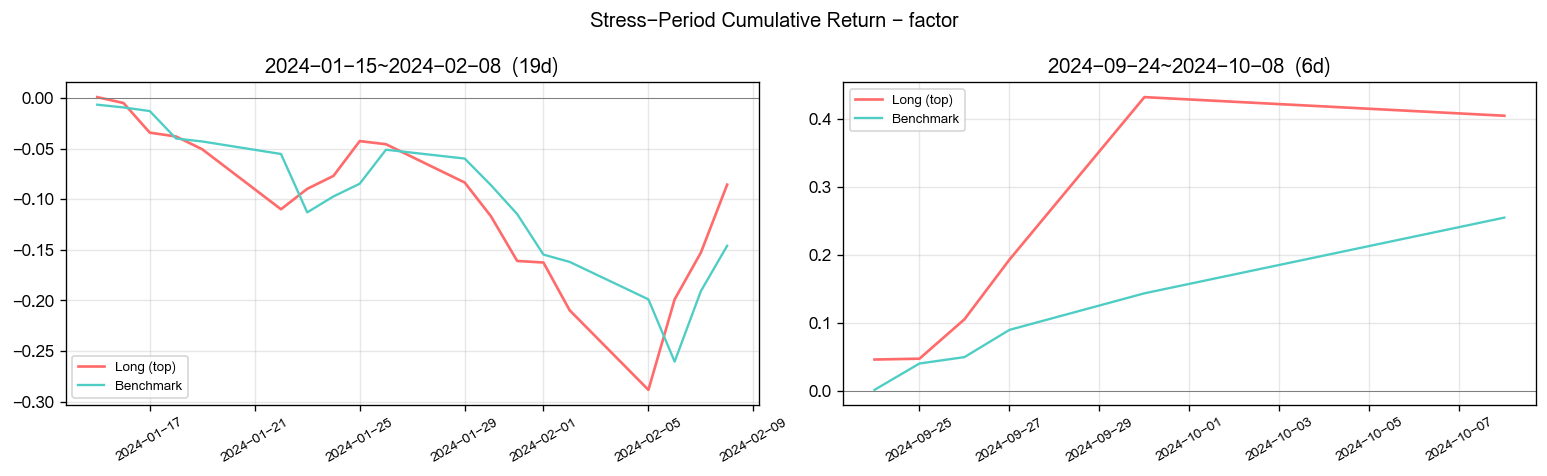

[2026-07-26 21:43:45] [info     ] ========== 因子池回归 ==========
[2026-07-26 21:43:45] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-26 21:43:57] [info     ] 获取收益率数据, 耗时: 11.4893 秒
[2026-07-26 21:43:57] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.1313 秒
[2026-07-26 21:43:57] [info     ] 统计 回归结果, 耗时: 0.0814 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,4.2928,0.0714,0.0166,1.0000
2,pb,1.8096,0.0111,0.0061,1.0000
3,rsi_12,1.7971,0.0438,0.0244,1.0000
4,total_market_cap,1.6964,0.0195,0.0115,1.0000
5,net_profit_rate_ttm,1.6497,0.0032,0.0019,1.0000
6,gross_profit_rate_ttm,1.4761,0.0060,0.0041,1.0000
7,float_market_cap,1.3849,0.0222,0.0160,0.9000
8,netflow_amount_main,1.3775,0.0233,0.0169,0.9000
9,netflow_amount_rate_main,1.3716,0.0102,0.0074,1.0000
10,pe_ttm,1.3174,0.0029,0.0022,0.9000

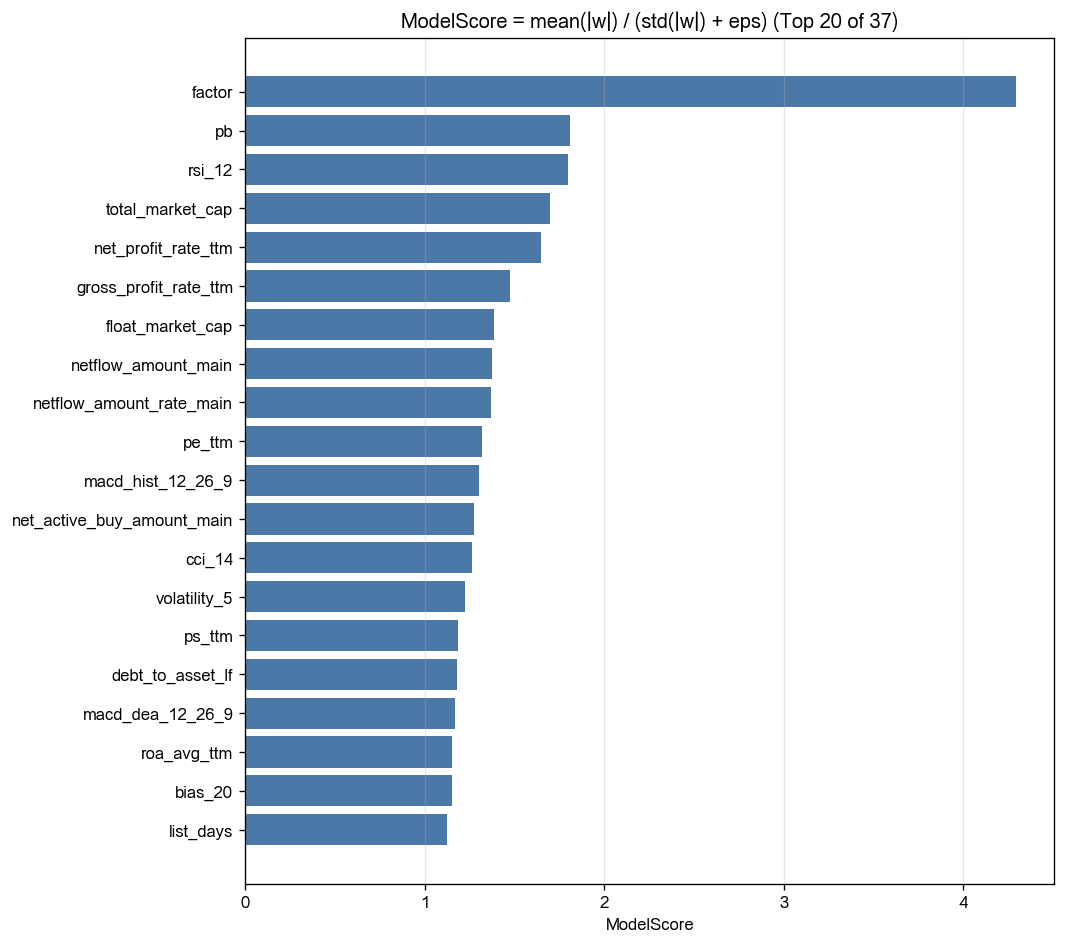
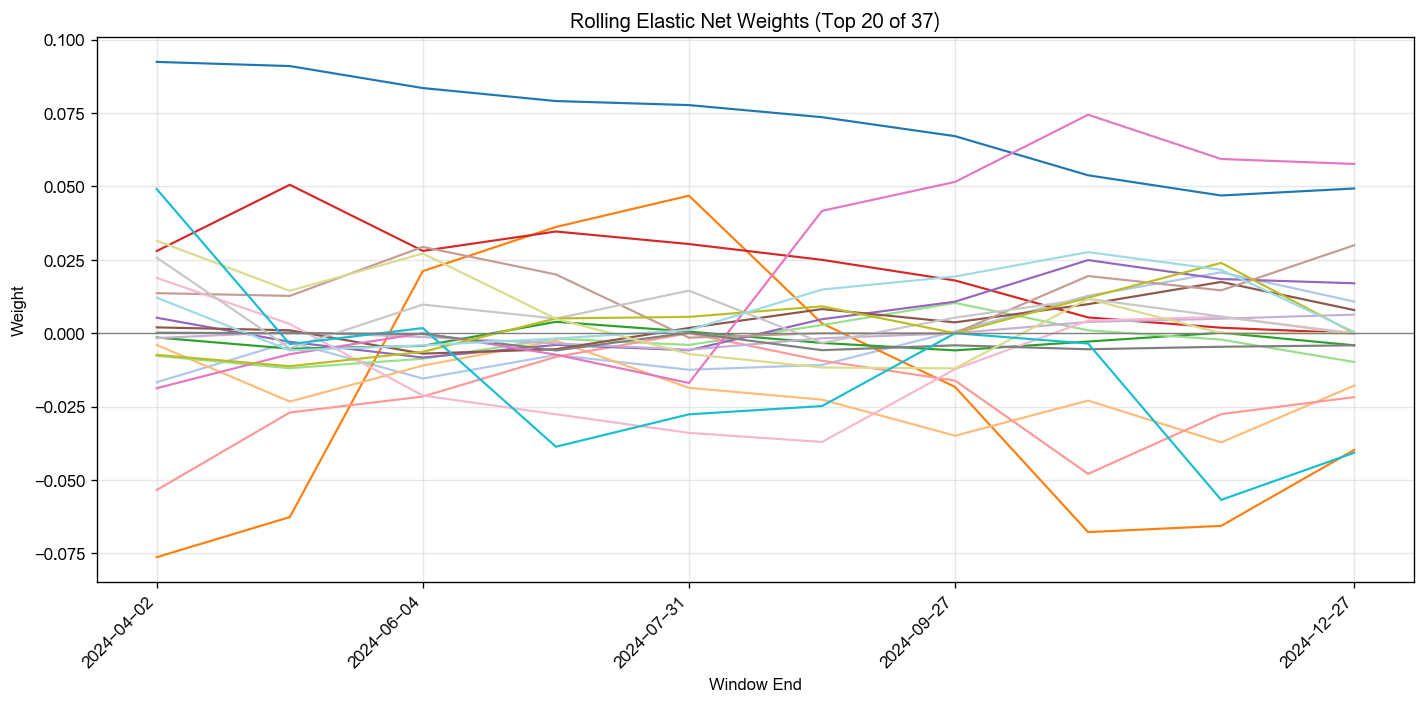
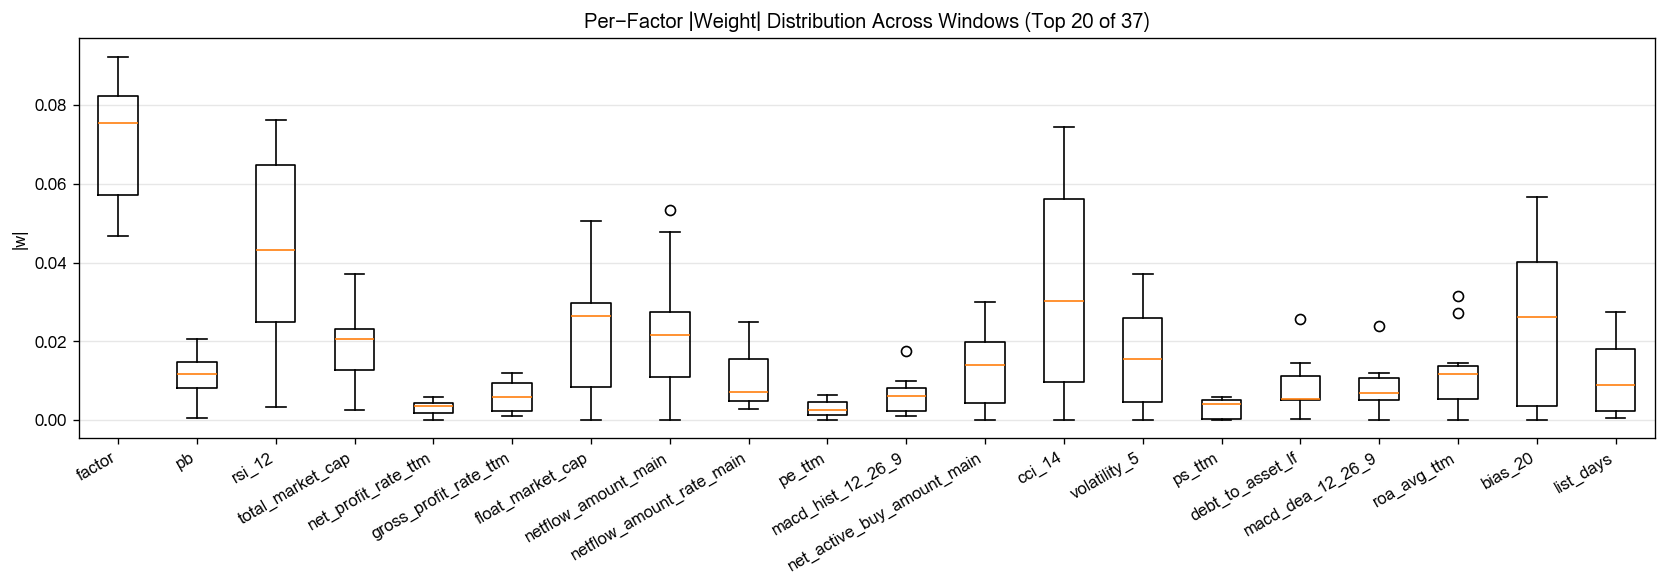
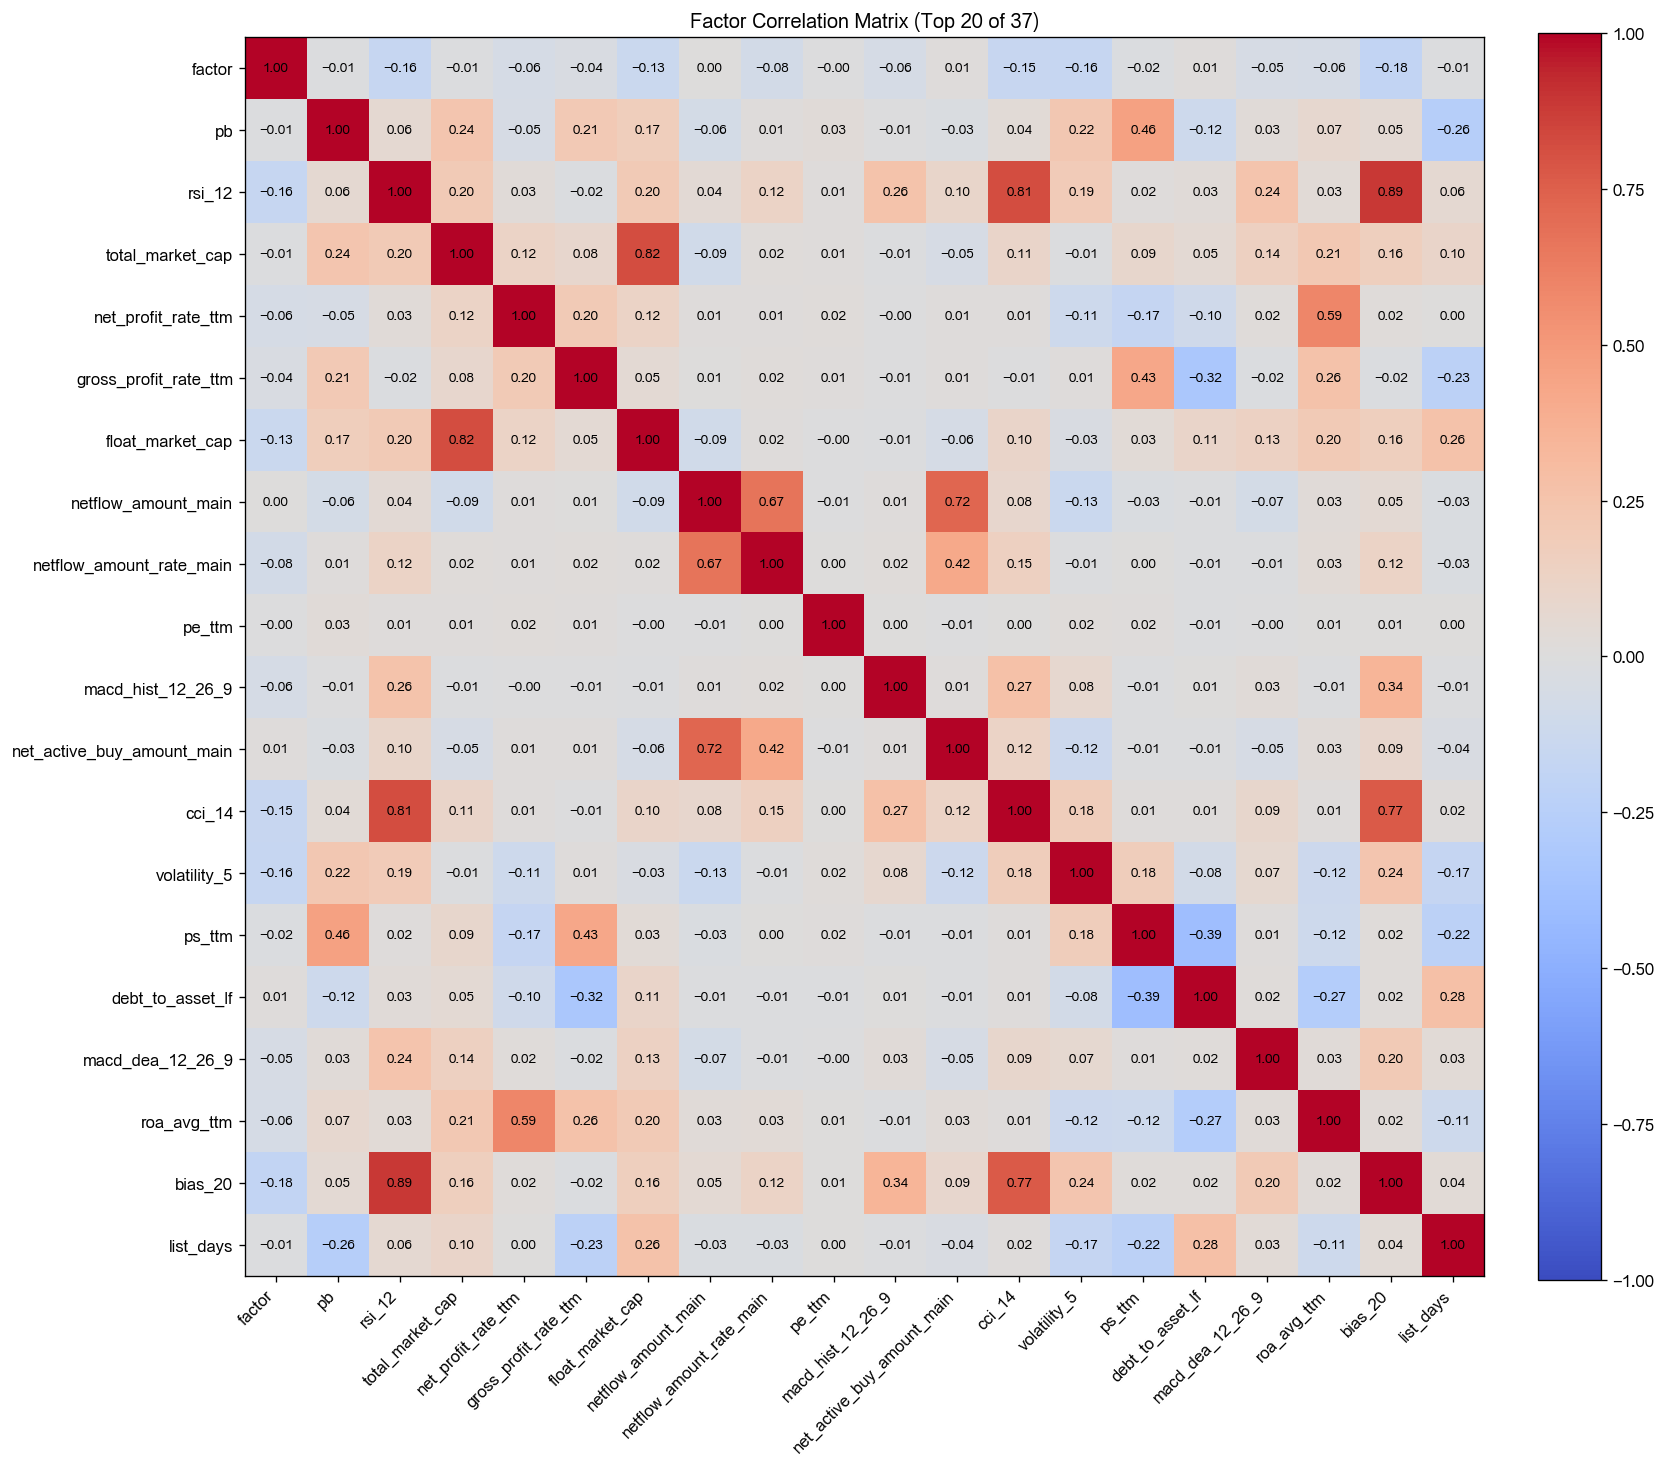

[2026-07-26 21:44:03] [warning  ] 返回的Outputs实例(size=35311801) 大于 64K, 将不会被缓存
[2026-07-26 21:44:03] [info     ] bigalpha_eval.v4 运行完成 [31.982s].


In [5]:
if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m"
    }

    start_date = "2024-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )